In [1]:
!pip install -q kagglehub seaborn

In [2]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Conv2DTranspose,
    BatchNormalization,
    Activation,
    Dropout,
    Add,
    Multiply,
    Concatenate,
    GlobalAveragePooling2D,
    Dense
)

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU available:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPU detected.")

print("Num GPUs Available:", len(gpus))

GPU available:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
Num GPUs Available: 2


In [4]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [5]:
import kagglehub

path = kagglehub.dataset_download(
    "shafiullahshafin/c-nmc-2019-dataset"
)

base = os.path.join(
    path,
    "C-NMC 2019 (PKG)",
    "C-NMC_training_data"
)

print("Dataset path:")
print(base)

Dataset path:
/kaggle/input/datasets/shafiullahshafin/c-nmc-2019-dataset/C-NMC 2019 (PKG)/C-NMC_training_data


In [6]:
def create_df(folder):
    files = []
    labels = []

    for root, _, f in os.walk(folder):
        for file in f:

            if file.lower().endswith(".bmp"):
                files.append(os.path.join(root, file))

                if "all" in root.lower():
                    labels.append("leukemia")
                else:
                    labels.append("normal")

    return pd.DataFrame({
        "file": files,
        "label": labels
    })


df = pd.concat([
    create_df(os.path.join(base, "fold_0")),
    create_df(os.path.join(base, "fold_1")),
    create_df(os.path.join(base, "fold_2"))
], ignore_index=True)

df = df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Total images:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

Total images: 10661

Class distribution:
label
leukemia    7272
normal      3389
Name: count, dtype: int64


In [8]:
print("Dataset shape:", df.shape)

print("\nClass mapping:")
print({
    "leukemia": 0,
    "normal": 1
})

print("\nClass distribution:")
print(df["label"].value_counts())

Dataset shape: (10661, 2)

Class mapping:
{'leukemia': 0, 'normal': 1}

Class distribution:
label
leukemia    7272
normal      3389
Name: count, dtype: int64


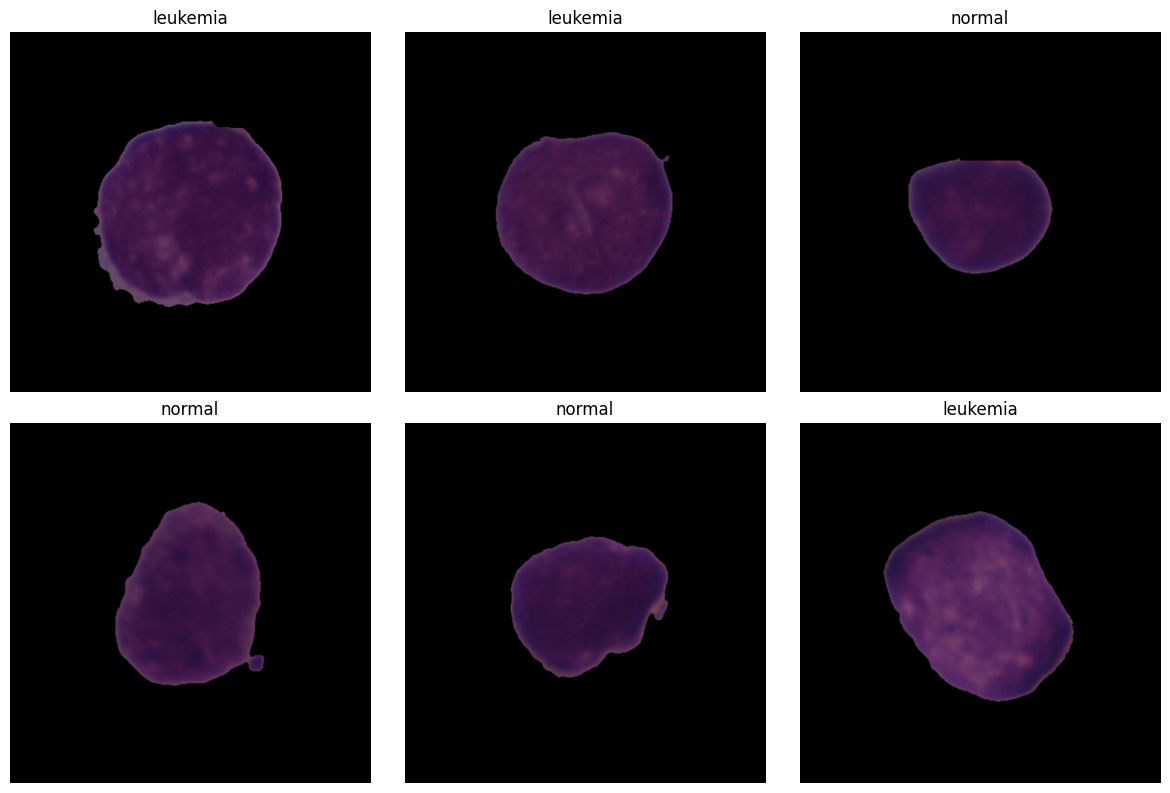

In [9]:
sample_df = df.sample(
    6,
    random_state=SEED
)

plt.figure(figsize=(12, 8))

for idx, (_, row) in enumerate(sample_df.iterrows()):

    image = cv2.imread(row["file"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, idx + 1)
    plt.imshow(image)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

Training images: 8528
Validation images: 2133

Training distribution:
label
leukemia    5817
normal      2711
Name: count, dtype: int64

Validation distribution:
label
leukemia    1455
normal       678
Name: count, dtype: int64


In [11]:
IMG_SIZE = 224
BATCH_SIZE = 16

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: 224
Batch size: 16


In [12]:
train_gen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(
    rescale=1.0 / 255
)

In [13]:
train_data = train_gen.flow_from_dataframe(
    train_df,
    x_col="file",
    y_col="label",
    classes=["leukemia", "normal"],
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("\nClass indices:")
print(train_data.class_indices)

Found 8528 validated image filenames belonging to 2 classes.

Class indices:
{'leukemia': 0, 'normal': 1}


In [14]:
val_data = val_gen.flow_from_dataframe(
    val_df,
    x_col="file",
    y_col="label",
    classes=["leukemia", "normal"],
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nValidation class indices:")
print(val_data.class_indices)

Found 2133 validated image filenames belonging to 2 classes.

Validation class indices:
{'leukemia': 0, 'normal': 1}


In [15]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(
    enumerate(weights)
)

print("Class weights:")
print(class_weights)

Class weights:
{0: np.float64(0.7330238954787691), 1: np.float64(1.5728513463666545)}


In [16]:
def conv_block(x, filters, dropout_rate=0.0):

    x = Conv2D(
        filters,
        (3, 3),
        padding="same",
        kernel_initializer="he_normal"
    )(x)

    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(
        filters,
        (3, 3),
        padding="same",
        kernel_initializer="he_normal"
    )(x)

    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)

    return x

In [17]:
def attention_gate(skip, gating, filters):

    theta_x = Conv2D(
        filters,
        (1, 1),
        padding="same"
    )(skip)

    phi_g = Conv2D(
        filters,
        (1, 1),
        padding="same"
    )(gating)

    attention = Add()([
        theta_x,
        phi_g
    ])

    attention = Activation("relu")(attention)

    attention = Conv2D(
        1,
        (1, 1),
        padding="same"
    )(attention)

    attention = Activation("sigmoid")(attention)

    attention = Multiply()([
        skip,
        attention
    ])

    return attention

In [18]:
def build_attention_encoder_decoder(
    input_shape=(224, 224, 3)
):

    inputs = Input(
        shape=input_shape,
        name="blood_cell_input"
    )

    # ==========================================
    # ENCODER
    # ==========================================

    # Encoder Block 1
    e1 = conv_block(
        inputs,
        32,
        dropout_rate=0.05
    )

    p1 = MaxPooling2D(
        (2, 2)
    )(e1)

    # Encoder Block 2
    e2 = conv_block(
        p1,
        64,
        dropout_rate=0.10
    )

    p2 = MaxPooling2D(
        (2, 2)
    )(e2)

    # Encoder Block 3
    e3 = conv_block(
        p2,
        128,
        dropout_rate=0.15
    )

    p3 = MaxPooling2D(
        (2, 2)
    )(e3)

    # Encoder Block 4
    e4 = conv_block(
        p3,
        256,
        dropout_rate=0.20
    )

    p4 = MaxPooling2D(
        (2, 2)
    )(e4)

    # ==========================================
    # BOTTLENECK
    # ==========================================

    bottleneck = conv_block(
        p4,
        512,
        dropout_rate=0.30
    )

    # ==========================================
    # DECODER
    # ==========================================

    # Decoder 4
    d4 = Conv2DTranspose(
        256,
        (2, 2),
        strides=(2, 2),
        padding="same"
    )(bottleneck)

    a4 = attention_gate(
        e4,
        d4,
        256
    )

    d4 = Concatenate()([
        d4,
        a4
    ])

    d4 = conv_block(
        d4,
        256,
        dropout_rate=0.20
    )

    # Decoder 3
    d3 = Conv2DTranspose(
        128,
        (2, 2),
        strides=(2, 2),
        padding="same"
    )(d4)

    a3 = attention_gate(
        e3,
        d3,
        128
    )

    d3 = Concatenate()([
        d3,
        a3
    ])

    d3 = conv_block(
        d3,
        128,
        dropout_rate=0.15
    )

    # Decoder 2
    d2 = Conv2DTranspose(
        64,
        (2, 2),
        strides=(2, 2),
        padding="same"
    )(d3)

    a2 = attention_gate(
        e2,
        d2,
        64
    )

    d2 = Concatenate()([
        d2,
        a2
    ])

    d2 = conv_block(
        d2,
        64,
        dropout_rate=0.10
    )

    # Decoder 1
    d1 = Conv2DTranspose(
        32,
        (2, 2),
        strides=(2, 2),
        padding="same"
    )(d2)

    a1 = attention_gate(
        e1,
        d1,
        32
    )

    d1 = Concatenate()([
        d1,
        a1
    ])

    d1 = conv_block(
        d1,
        32,
        dropout_rate=0.05
    )

    # ==========================================
    # CLASSIFICATION HEAD
    # ==========================================

    features = GlobalAveragePooling2D(
        name="global_average_pooling"
    )(d1)

    features = Dense(
        128,
        activation="relu",
        name="classification_features"
    )(features)

    features = Dropout(
        0.5
    )(features)

    output = Dense(
        1,
        activation="sigmoid",
        name="leukemia_probability"
    )(features)

    model = Model(
        inputs=inputs,
        outputs=output,
        name="Attention_Encoder_Decoder_Classifier"
    )

    return model

In [20]:
model = build_attention_encoder_decoder(
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

model.summary()

I0000 00:00:1790137960.170902      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790137960.173737      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Attention_Encoder_Decoder_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ blood_cell_input    │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ blood_cell_input… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 224, 224,  │          0 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 112, 112,  │          0 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ dropout_1[0][0] 

 Total params: 7,951,717 (30.33 MB)

 Trainable params: 7,945,829 (30.31 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [21]:
model.compile(
    optimizer=Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy"
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [22]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "/kaggle/working/best_attention_encoder_decoder.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [23]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20


2026-09-23 04:33:47.275160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 04:33:47.437692: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 04:33:49.903127: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 04:33:50.194995: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 04:33:51.868717: E external/local_xla/xla/stream_

533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.7148 - loss: 0.5808

2026-09-23 04:38:08.030226: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 04:38:08.190192: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.38772, saving model to /kaggle/working/best_attention_encoder_decoder.keras

Epoch 1: finished saving model to /kaggle/working/best_attention_encoder_decoder.keras
533/533 ━━━━━━━━━━━━━━━━━━━━ 289s 438ms/step - accuracy: 0.7711 - loss: 0.5022 - val_accuracy: 0.3877 - val_loss: 1.5033 - learning_rate: 1.0000e-04
Epoch 2/20
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8351 - loss: 0.4016
Epoch 2: val_accuracy improved from 0.38772 to 0.83544, saving model to /kaggle/working/best_attention_encoder_decoder.keras

Epoch 2: finished saving model to /kaggle/working/best_attention_encoder_decoder.keras
533/533 ━━━━━━━━━━━━━━━━━━━━ 176s 329ms/step - accuracy: 0.8370 - loss: 0.4009 - val_accuracy: 0.8354 - val_loss: 0.3677 - learning_rate: 1.0000e-04
Epoch 3/20
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8341 - loss: 0.3857
Epoch 3: val_accuracy did not improve from 0.83544
533/533 ━━━━━━━━━━━━━━━━━━━━ 174s 327ms/step - accu

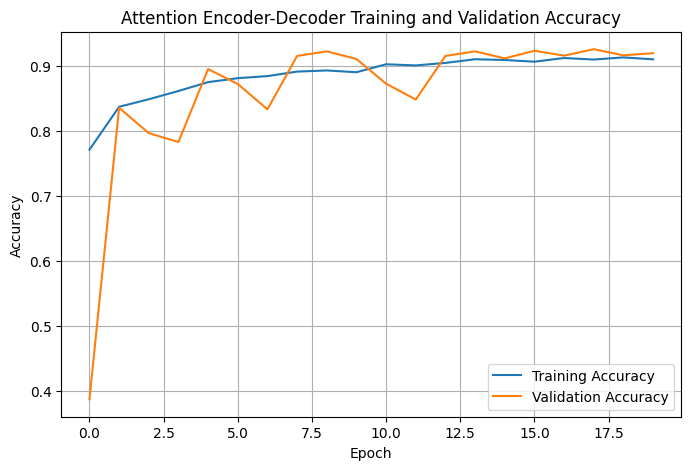

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Attention Encoder-Decoder Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)
plt.show()

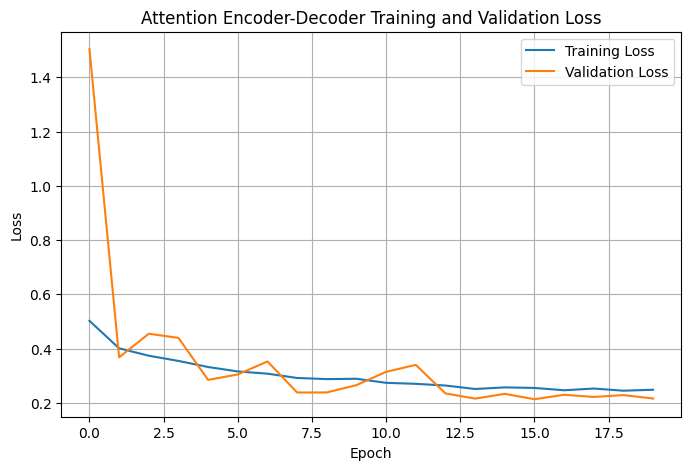

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Attention Encoder-Decoder Training and Validation Loss"
)

plt.legend()
plt.grid(True)
plt.show()

In [26]:
best_model = load_model(
    "/kaggle/working/best_attention_encoder_decoder.keras"
)

print("Best model loaded successfully.")

Best model loaded successfully.


In [27]:
val_data.reset()

pred_prob = best_model.predict(
    val_data,
    verbose=1
).ravel()

pred_label = (
    pred_prob >= 0.5
).astype(int)

y_true = val_data.classes

print("Predictions generated.")

134/134 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step
Predictions generated.


In [28]:
accuracy = accuracy_score(
    y_true,
    pred_label
)

precision = precision_score(
    y_true,
    pred_label
)

recall = recall_score(
    y_true,
    pred_label
)

f1 = f1_score(
    y_true,
    pred_label
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9255
Precision: 0.9361
Recall   : 0.8215
F1 Score : 0.8751


In [29]:
print(
    classification_report(
        y_true,
        pred_label,
        target_names=[
            "Leukemia",
            "Normal"
        ]
    )
)

              precision    recall  f1-score   support

    Leukemia       0.92      0.97      0.95      1455
      Normal       0.94      0.82      0.88       678

    accuracy                           0.93      2133
   macro avg       0.93      0.90      0.91      2133
weighted avg       0.93      0.93      0.92      2133



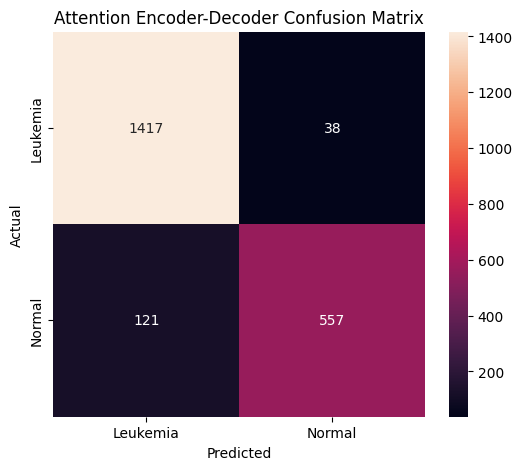

In [30]:
cm = confusion_matrix(
    y_true,
    pred_label
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Leukemia", "Normal"],
    yticklabels=["Leukemia", "Normal"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "Attention Encoder-Decoder Confusion Matrix"
)

plt.show()

In [31]:
model_path = "/kaggle/working/attention_encoder_decoder_classifier.keras"

best_model.save(
    model_path
)

print("Model saved at:")
print(model_path)

Model saved at:
/kaggle/working/attention_encoder_decoder_classifier.keras


In [52]:
def make_gradcam_heatmap(
    img_array,
    model,
    layer_name
):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, prediction = grad_model(
            img_array
        )

        # Sigmoid output represents class 1 = Normal
        normal_probability = prediction[:, 0]

        leukemia_probability = (
            1.0 - normal_probability
        )

        # Explain whichever class was predicted
        if leukemia_probability[0] >= 0.5:
            target = leukemia_probability
        else:
            target = normal_probability

    grads = tape.gradient(
        target,
        conv_outputs
    )

    # Average gradients across spatial dimensions
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weighted combination of feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(
        heatmap
    )

    heatmap = heatmap / (
        max_value +
        tf.keras.backend.epsilon()
    )

    return heatmap.numpy()

In [48]:
# Show existing Conv2D layers in the trained model

for layer in best_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(
            layer.name,
            "->",
            layer.output.shape
        )

conv2d -> (None, 224, 224, 32)
conv2d_1 -> (None, 224, 224, 32)
conv2d_2 -> (None, 112, 112, 64)
conv2d_3 -> (None, 112, 112, 64)
conv2d_4 -> (None, 56, 56, 128)
conv2d_5 -> (None, 56, 56, 128)
conv2d_6 -> (None, 28, 28, 256)
conv2d_7 -> (None, 28, 28, 256)
conv2d_8 -> (None, 14, 14, 512)
conv2d_9 -> (None, 14, 14, 512)
conv2d_10 -> (None, 28, 28, 256)
conv2d_11 -> (None, 28, 28, 256)
conv2d_12 -> (None, 28, 28, 1)
conv2d_13 -> (None, 28, 28, 256)
conv2d_14 -> (None, 28, 28, 256)
conv2d_15 -> (None, 56, 56, 128)
conv2d_16 -> (None, 56, 56, 128)
conv2d_17 -> (None, 56, 56, 1)
conv2d_18 -> (None, 56, 56, 128)
conv2d_19 -> (None, 56, 56, 128)
conv2d_20 -> (None, 112, 112, 64)
conv2d_21 -> (None, 112, 112, 64)
conv2d_22 -> (None, 112, 112, 1)
conv2d_23 -> (None, 112, 112, 64)
conv2d_24 -> (None, 112, 112, 64)
conv2d_25 -> (None, 224, 224, 32)
conv2d_26 -> (None, 224, 224, 32)
conv2d_27 -> (None, 224, 224, 1)
conv2d_28 -> (None, 224, 224, 32)
conv2d_29 -> (None, 224, 224, 32)


In [34]:
class_indices = {
    "leukemia": 0,
    "normal": 1
}

inverse_map = {
    0: "Leukemia",
    1: "Normal"
}

In [42]:
def predict_single_image(img_path, model):

    img = load_img(
        img_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = img_to_array(img) / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Sigmoid output = probability of class 1 = Normal
    normal_probability = model.predict(
        img_array,
        verbose=0
    )[0][0]

    leukemia_probability = 1 - normal_probability

    if normal_probability >= 0.5:
        label = "Normal"
    else:
        label = "Leukemia"

    print(f"Leukemia Probability: {leukemia_probability:.4f}")
    print(f"Normal Probability: {normal_probability:.4f}")
    print(f"Final Prediction: {label}")

    plt.figure(figsize=(5, 5))

    plt.imshow(img)

    plt.title(
        f"Prediction: {label}"
    )

    plt.axis("off")
    plt.show()

    return leukemia_probability, normal_probability, label

Testing image:
/kaggle/input/datasets/shafiullahshafin/c-nmc-2019-dataset/C-NMC 2019 (PKG)/C-NMC_training_data/fold_0/all/UID_35_13_7_all.bmp
Leukemia Probability: 0.9696
Normal Probability: 0.0304
Final Prediction: Leukemia


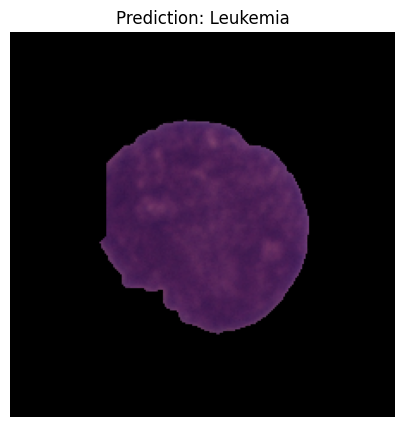

In [47]:
test_image = val_df.iloc[0]["file"]

print("Testing image:")
print(test_image)

leukemia_prob, normal_prob, label = predict_single_image(
    test_image,
    best_model
)

In [49]:
conv_layers = []

for layer in best_model.layers:

    if isinstance(layer, tf.keras.layers.Conv2D):

        shape = layer.output.shape

        if shape[1] is not None and shape[2] is not None:

            conv_layers.append(
                (
                    layer.name,
                    int(shape[1]),
                    int(shape[2]),
                    int(shape[-1])
                )
            )

print("Available convolution layers:\n")

for item in conv_layers:
    print(item)

Available convolution layers:

('conv2d', 224, 224, 32)
('conv2d_1', 224, 224, 32)
('conv2d_2', 112, 112, 64)
('conv2d_3', 112, 112, 64)
('conv2d_4', 56, 56, 128)
('conv2d_5', 56, 56, 128)
('conv2d_6', 28, 28, 256)
('conv2d_7', 28, 28, 256)
('conv2d_8', 14, 14, 512)
('conv2d_9', 14, 14, 512)
('conv2d_10', 28, 28, 256)
('conv2d_11', 28, 28, 256)
('conv2d_12', 28, 28, 1)
('conv2d_13', 28, 28, 256)
('conv2d_14', 28, 28, 256)
('conv2d_15', 56, 56, 128)
('conv2d_16', 56, 56, 128)
('conv2d_17', 56, 56, 1)
('conv2d_18', 56, 56, 128)
('conv2d_19', 56, 56, 128)
('conv2d_20', 112, 112, 64)
('conv2d_21', 112, 112, 64)
('conv2d_22', 112, 112, 1)
('conv2d_23', 112, 112, 64)
('conv2d_24', 112, 112, 64)
('conv2d_25', 224, 224, 32)
('conv2d_26', 224, 224, 32)
('conv2d_27', 224, 224, 1)
('conv2d_28', 224, 224, 32)
('conv2d_29', 224, 224, 32)


In [50]:
# Prefer a deep feature layer around 14x14
candidate_layers = [
    x for x in conv_layers
    if x[1] <= 28
]

# Select the layer with the largest number of channels
selected_layer = max(
    candidate_layers,
    key=lambda x: x[3]
)

CONV_LAYER_NAME = selected_layer[0]

print("Selected Grad-CAM layer:", CONV_LAYER_NAME)
print("Layer shape:", selected_layer[1:])

Selected Grad-CAM layer: conv2d_8
Layer shape: (14, 14, 512)


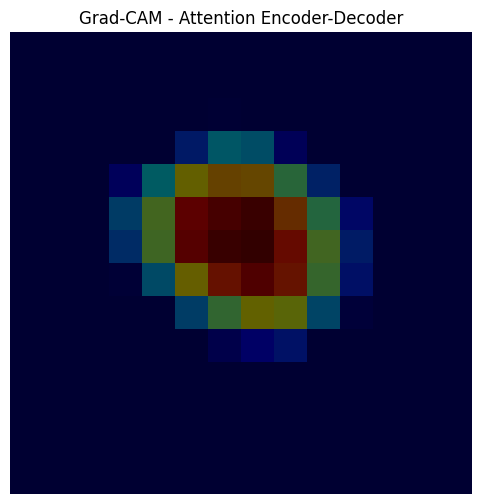

In [53]:
CONV_LAYER_NAME = "conv2d_8"
img = load_img(
    test_image,
    target_size=(IMG_SIZE, IMG_SIZE)
)

img_array = img_to_array(
    img
) / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

heatmap = make_gradcam_heatmap(
    img_array,
    best_model,
    CONV_LAYER_NAME
)

plt.figure(figsize=(6, 6))

plt.imshow(
    img
)

plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.4
)

plt.title(
    "Grad-CAM - Attention Encoder-Decoder"
)

plt.axis("off")

plt.show()

In [56]:
img = load_img(
    test_image,
    target_size=(IMG_SIZE, IMG_SIZE)
)

img_array = img_to_array(img) / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

heatmap = make_gradcam_heatmap(
    img_array,
    best_model,
    CONV_LAYER_NAME
)

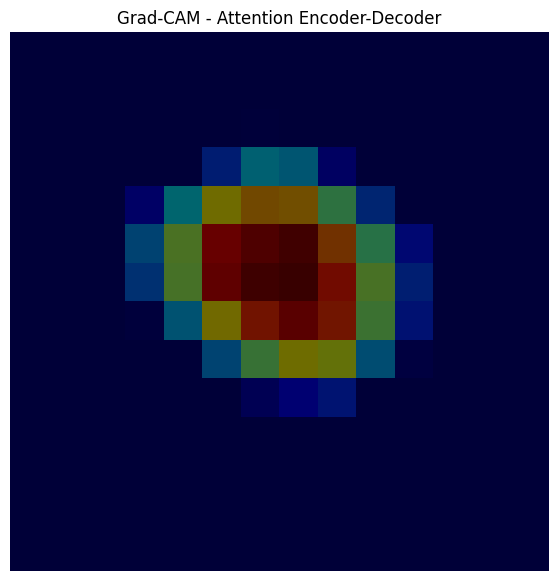

In [57]:
plt.figure(figsize=(7, 7))

plt.imshow(img)

plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.45
)

plt.title(
    "Grad-CAM - Attention Encoder-Decoder"
)

plt.axis("off")

plt.show()

In [46]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Attention Encoder-Decoder": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results

,Metric,Attention Encoder-Decoder
0,Accuracy,0.925457
1,Precision,0.936134
2,Recall,0.821534
3,F1 Score,0.875098
